# ML from DFT data

- [ ] learn on separated FM and NM AGAIN
- [ ] remove high order BOP features before learing
- [X] Recursive Feature elimination after removing high order features
- [ ] make recursion on bond energy
- [X] change OS to 1/10,
- [X] 1/10 OS and scf bop
- [ ] scaled bond integrals
- learn form library features
- compare different regression methods
   - Linear regression
   - add SVM
   - kernel methods
   - Gaussian process.
- compare different test-train splittings
- Learn on increasing domain knowledge

 - input: clean features dataframes from pickles
 - output : plots and Models

In [1]:
from Tools.DatasetTools.Commoms import *
from Tools.DatasetTools.DatasetOperator import Dataset, DatasetTester

In [2]:
from Tools.DatasetTools.Tools import get_str_formatted
from sklearn.model_selection import StratifiedKFold

In [3]:
import matplotlib
from matplotlib.ticker import FormatStrFormatter

In [4]:
plt.rc('figure', figsize=(18, 8))
plt.rc('font', size=26)
plt.rc('xtick', labelsize=26)
plt.rc('ytick', labelsize=26)
plt.rc('axes', labelsize=30)
from matplotlib.lines import Line2D

# Parameters 

In [5]:
target_case = 'EF_nmhcp'

In [6]:
DS = Dataset('Fe-Mo', target_name=target_case)

Possible models are: **Kernel Ridge, MLP and Random Forest**

In [7]:
ModelName = 'Kernel Ridge'

In [8]:
suffix = "FixedOS" #'CV_restart_folds_inloop''CV_restart_folds_inloop'

# Targets

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


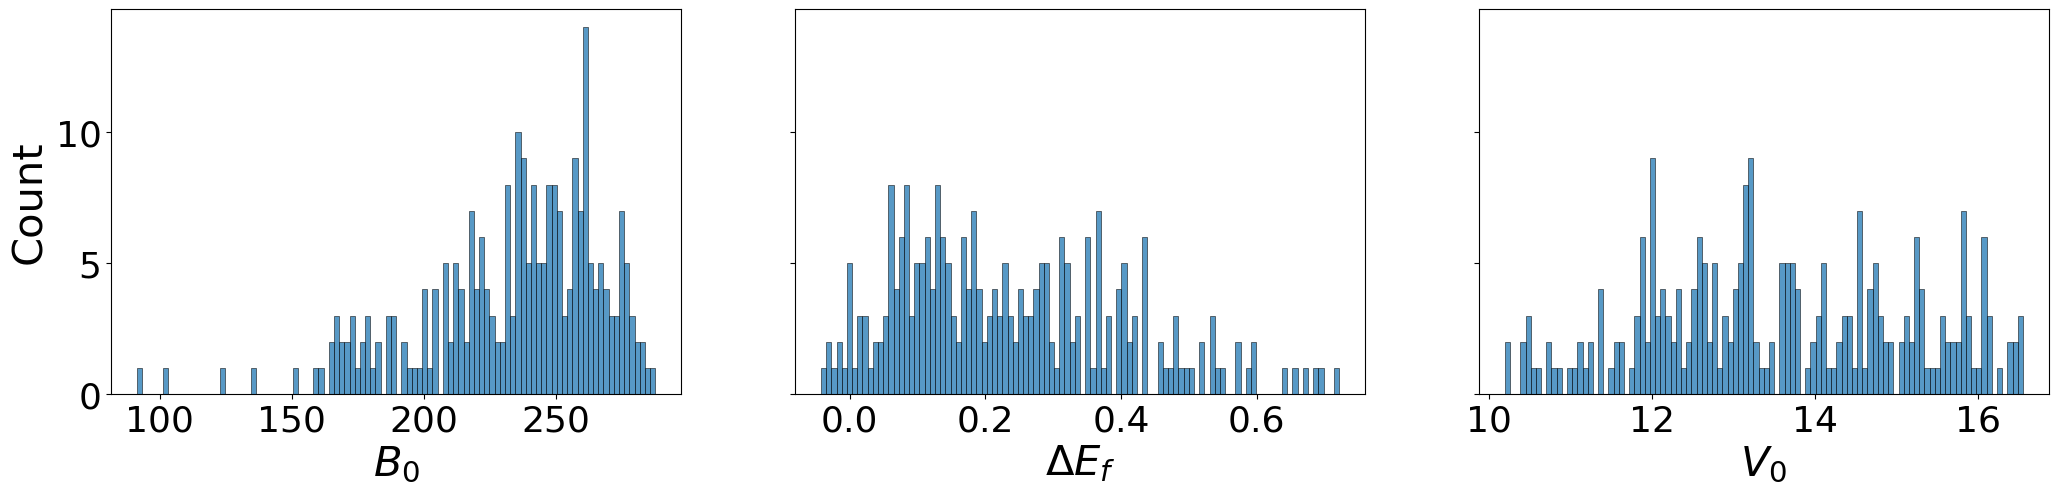

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(25, 5), sharey = True)
sns.histplot( DS.BS['B0'], ax= ax[0], bins=100)
sns.histplot( DS.BS[target_case], ax= ax[1], bins=100)
sns.histplot( DS.BS['V0'], ax= ax[2], bins = 100)
ax[0].set_xlabel('$B_0$')
ax[1].set_xlabel(r'$\Delta E_f$')
ax[2].set_xlabel('$V_0$')
fig.savefig(f'{DS.dataset}/graphs/{DS.dataset}_target_distributions_{target_case}.eps')

In [10]:
DS.BS.B0.idxmax()

'Fe_pv2.hcp.NM'

In [11]:
DS.BS.query('B0 < 150')

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,atom_B,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,EF_nmhcp,EF_nmfcc,EF_fmbcc,Phase
Fe_pv12.C14.FM,bulk C14.FM,12.119019 A,-8.105991,102.152576 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,,12,0,12,1.000000,0.000000,0.149303,0.149303,0.149303,C14
Fe_pv8.A15.FM,bulk A15.FM,11.558019 A,-8.169759,91.497861 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,,8,0,8,1.000000,0.000000,0.085535,0.085535,0.085535,A15
Fe_pv25Mo_sv4.chi-ABAA.FM,bulk chi-ABAA.FM,11.874474 A,-8.560894,134.837320 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,25,4,29,0.862069,0.137931,0.063911,0.063911,0.063911,chi
Fe_pv24Mo_sv5.chi-BBAA.FM,bulk chi-BBAA.FM,11.926180 A,-8.658669,124.301732 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,24,5,29,0.827586,0.172414,0.058514,0.058514,0.058514,chi


# Machine Learning 

In [12]:
from Tools.DatasetTools.MLConveniences import *

In [13]:
resultslocation = DS.resultslocation

## Feature sets

In [14]:
Features = DS.Features  # {name: pd.read_pickle(filename) for name, filename in DescriptorFileList.items()}

## BOP features with and without CP averages

In [15]:
# Features.update({name+' no Zeros': clean_zeros(name, features) for name, features in Features.items() if notyetclean(name)} )

## test - train splits

In [16]:
samplesplit = DS.get_samplesplit()

<AxesSubplot:xlabel='Phase', ylabel='Count'>

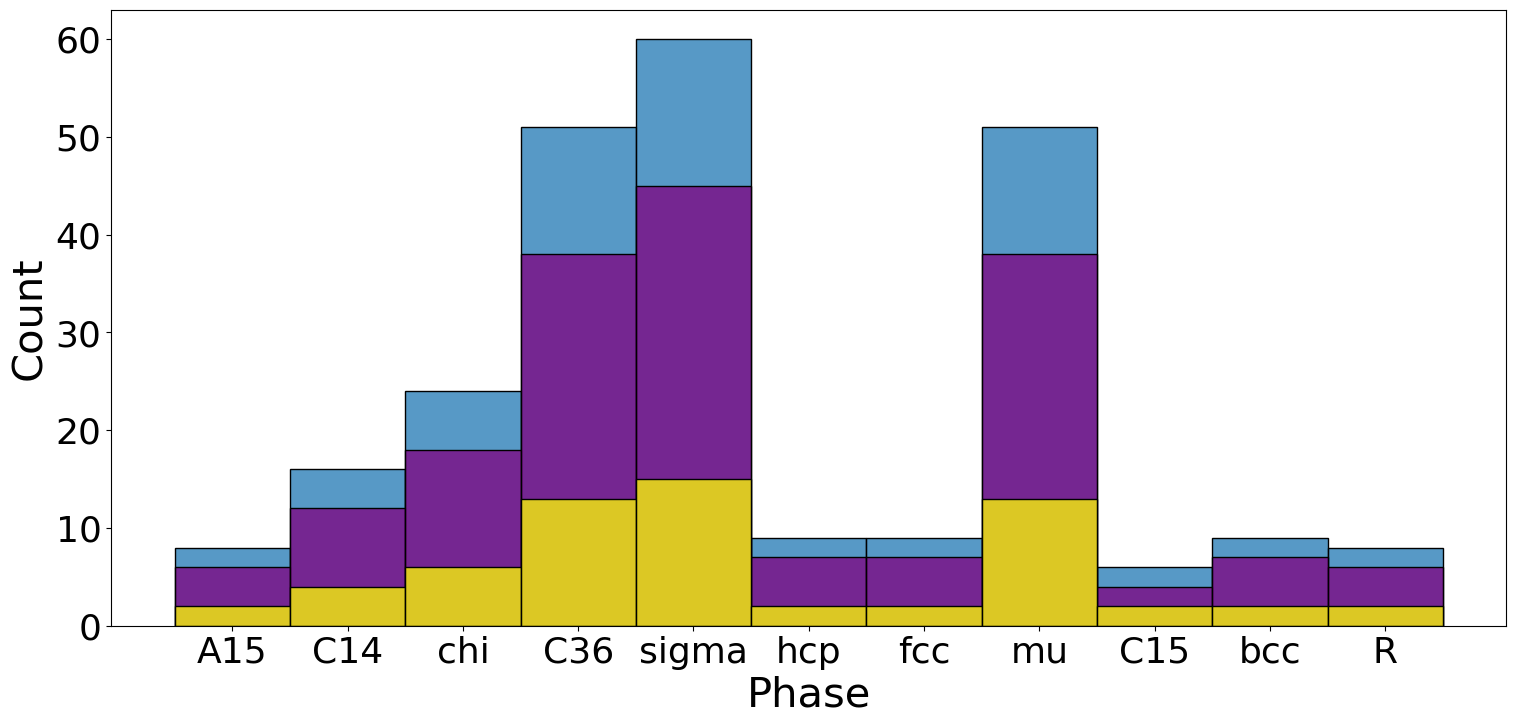

In [17]:
ax = sns.histplot(DS.StructureNames)
sns.histplot(DS.StructureNames.loc[samplesplit['train']], ax = ax, color = 'purple')
sns.histplot(DS.StructureNames.loc[samplesplit['test']], ax = ax, color = 'yellow')

# Models: adjust params

In [18]:
import warnings
warnings.simplefilter('ignore')

In [19]:
Models = {
    'Kernel Ridge': Pipeline([('scaler', StandardScaler()), ('regressor', KernelRidge())]),
    'MLP': Pipeline([('scaler', StandardScaler()), ('regressor', MLPRegressor())]),
    'Random Forest': Pipeline([('regressor', RandomForestRegressor())]),
    'Gaussian Process': Pipeline([('regressor', GaussianProcessRegressor())])
}

In [20]:
from importlib.machinery import SourceFileLoader
MO = SourceFileLoader('MO', 'Tools/DatasetTools/ModelSelection.py').load_module().ModelOptions(DS.dataset)

In [21]:
MO.load_model_options(ModelName)

In [22]:
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, RationalQuadratic, ConstantKernel, ExpSineSquared, DotProduct, Product

##  Features

In [23]:
DS.BS.index[DS.BS.index.str.contains('bcc')]

Index(['Mo_sv1.bcc.FM', 'Mo_sv1.bcc.NM', 'Fe_pv1.bcc.NM', 'Fe_pv1.bcc.FM'], dtype='object')

In [24]:
Features['Projections OS BOP'].index[Features['Projections OS BOP'].index.str.contains('bcc')]

Index(['Fe_pv1.bcc.FM', 'Mo_sv1.bcc.NM', 'Mo_sv1.bcc.FM', 'Fe_pv1.bcc.NM'], dtype='object')

In [25]:
Features['0.7 Projections OS BOP'].index[Features['0.7 Projections OS BOP'].index.str.contains('bcc')]

Index(['Fe_pv1.bcc.FM', 'Mo_sv1.bcc.NM', 'Mo_sv1.bcc.FM', 'Fe_pv1.bcc.NM'], dtype='object')

In [26]:
DS.target.index.difference(Features['Projections OS BOP'].index)

Index([], dtype='object')

In [27]:
for name, thefeatures in Features.items():
    print(name, thefeatures.shape)

atomic (251, 135)
dataset (251, 32)
SOAP_canonicalFe (251, 100)
SOAP_canonicalW (251, 100)
SOAP_specific (251, 198)
Pyscal (251, 15)
ACE (251, 1797)
Canonical BOP (251, 393)
Projections BOP (251, 393)
Projections OS BOP (251, 393)
0.6 Projections OS BOP (251, 393)
0.7 Projections OS BOP (251, 393)
0.8 Projections OS BOP (251, 393)
dataset + Canonical BOP (251, 422)
dataset + Projections BOP (251, 422)
dataset + Projections OS BOP (251, 422)
dataset + 0.6 Projections OS BOP (251, 422)
dataset + 0.7 Projections OS BOP (251, 422)
dataset + 0.8 Projections OS BOP (251, 422)
atomic no CNAV (251, 135)
dataset no CNAV (251, 17)
SOAP_canonicalFe no CNAV (251, 16)
SOAP_canonicalW no CNAV (251, 16)
SOAP_specific no CNAV (251, 75)
Pyscal no CNAV (251, 5)
ACE no CNAV (251, 302)
Canonical BOP no CNAV (251, 68)
Projections BOP no CNAV (251, 68)
Projections OS BOP no CNAV (251, 68)
0.6 Projections OS BOP no CNAV (251, 68)
0.7 Projections OS BOP no CNAV (251, 68)
0.8 Projections OS BOP no CNAV (251, 6

In [28]:
Features['0.7 Projections OS BOP'].index[Features['0.7 Projections OS BOP'].index.str.contains('bcc')]

Index(['Fe_pv1.bcc.FM', 'Mo_sv1.bcc.NM', 'Mo_sv1.bcc.FM', 'Fe_pv1.bcc.NM'], dtype='object')

# Feature Selection

In [29]:
feature_concat_resul_loc = os.path.join(DS.dataset, 'results', f'concatenation_results_{target_case}_{suffix}.pkl')  
if os.path.exists(feature_concat_resul_loc):
    with open(feature_concat_resul_loc, 'rb') as pkl:
        FCresults = pickle.load(pkl)
else:
    FCresults = {}

In [30]:
nowantoplot = ['0.6 Projections OS BOP','0.8 Projections OS BOP', 'Projections OS BOP', 'atomic no CNAV', 'dataset no CNAV', 'SOAP_canonicalFe']

In [31]:
iwanttoplot = [combi[1] for combi in FCresults.keys() if combi[0] == ModelName and combi[1] not in nowantoplot and len(FCresults[combi])>0]# and 'no CNAV' not in combi[1] and combi[1] != 'ACE']

In [32]:
iwanttoplot

['0.7 Projections OS BOP',
 'Canonical BOP',
 'SOAP_specific',
 'atomic',
 'dataset',
 '0.7 Projections OS BOP no CNAV',
 'Canonical BOP no CNAV',
 'SOAP_specific no CNAV',
 'ACE no CNAV',
 'ACE']

In [33]:
pallete = sns.color_palette(n_colors=len(iwanttoplot))

In [34]:
colors = {name: c for name, c in zip(iwanttoplot, pallete)}

In [35]:
# iwanttoplot = ['atomic', 'dataset', 'Canonical BOP', 'dataset + Canonical BOP', 'Projections BOP', 'dataset + Projections BOP', 'Projections sOS BOP', 'dataset + Projections sOS BOP' ]
#iwanttoplot = ['ACE','SOAP_specific',  'Canonical BOP', 
#iwanttoplot = ['Projections OS BOP']#, 'Projections sOS BOP']#, 'SOAP_canonicalW',

In [36]:
folder = StratifiedKFold(shuffle=True)
folds_generator = folder.split(DS.samplesplit['train'], DS.StructureNames[DS.samplesplit['train']])
train_folds = list(folds_generator)
TestCV = GridSearchCV(Models[ModelName], MO.modeloptions[ModelName], cv = train_folds, return_train_score=True)

In [37]:
FittedGS = {}

In [38]:
MO.modeloptions

{'Kernel Ridge': {'regressor__alpha': [1.0, 0.1, 0.01],
  'regressor__kernel': ['polynomial'],
  'regressor__degree': [2, 3, 4, 5],
  'regressor__coef0': [0, 1, 2, 3, 4, 5]}}

# DS.Features.keys(): #['Canonical BOP']:
for featurename in iwanttoplot: #FittedModels.items():
    print(featurename)
    if 'random' not in Features[featurename]:
        Features[featurename]['random'] = np.random.rand(DS.target.shape[0])
    corrs = pd.concat([Features[featurename], DS.target], axis=1).corr().abs()[target_case]
    
    reasonable_features = corrs[corrs > corrs['random']].index.difference([target_case])
    combi = (ModelName, featurename)
#   model = copy.deepcopy(fmodel.best_estimator_)
    if len(FCresults[combi]) >= 1 :
        continue
    FittedGS[combi] = copy.deepcopy(TestCV)
    FC = FeatureConcatenate(DS, FittedGS[combi],  MO.modeloptions[ModelName]) #fmodel.best_params_,)model_params_grid =
    FCresults[combi].append (FC.get_best_features_list(combi[1], num_features = 2, max_workers=3, search_only = reasonable_features))#DS.Features[combi[1]].shape[1]
    with open(feature_concat_resul_loc, 'wb') as pkl:
        pickle.dump(FCresults, pkl)

In [39]:
#with open(feature_concat_resul_loc, 'wb') as pkl:
#    pickle.dump(FCresults, pkl)

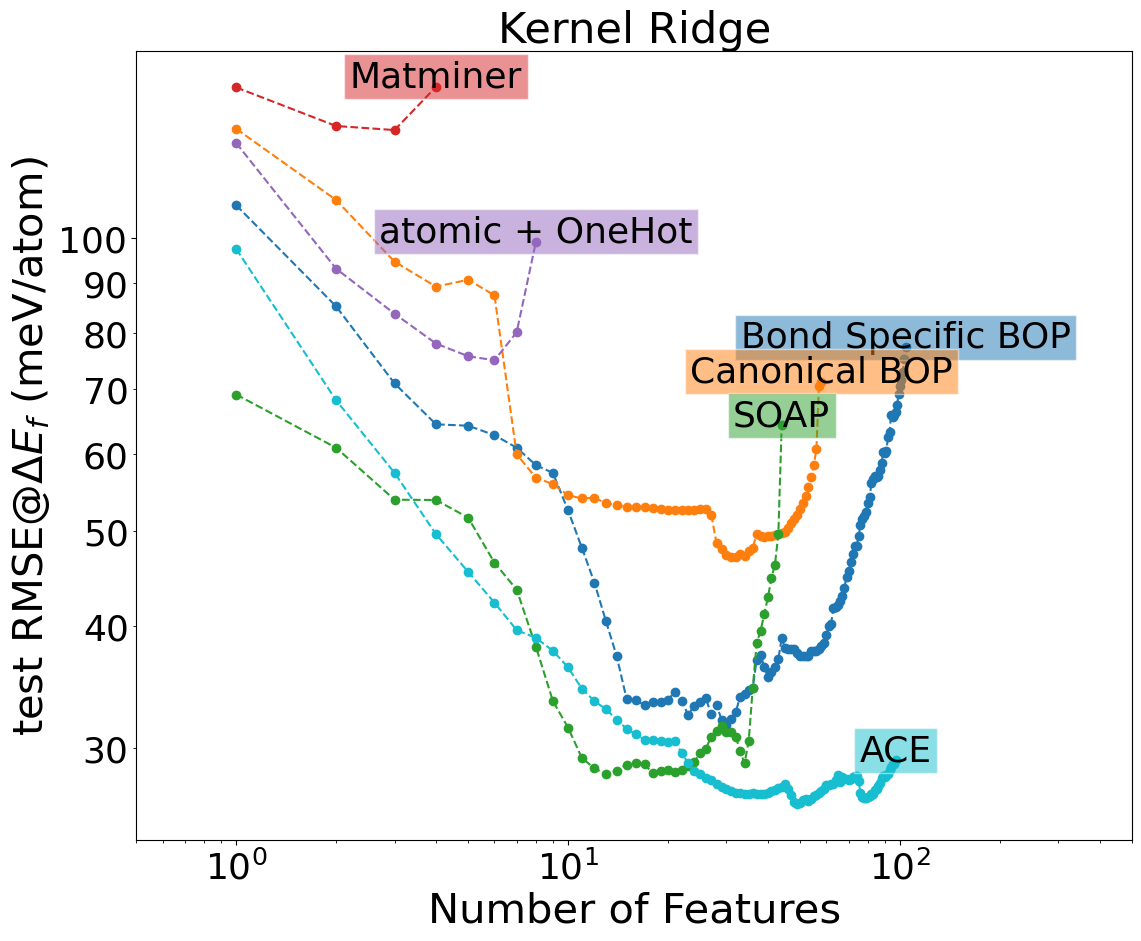

In [40]:
from matplotlib.ticker import FormatStrFormatter
fig, axes = plt.subplots(figsize=(12,10))
for combi, result in FCresults.items():
    if len(result) < 1:
        continue
    if combi[0] != ModelName:
        continue
    if combi[1] not in iwanttoplot:
        continue
    if 'no CNAV' in combi[1]:
        continue
#    if ' OS ' in combi[1]:
#        continue
    nfeats = result[-1].shape[0]
    x=np.linspace(1,nfeats, nfeats)
    legend = combi[1].replace('dataset', 'polyhedra')
    legend = legend.replace('atomic', 'Matminer')\
        .replace('_specific','').replace('0.7 ','')\
        .replace('polyhedra','atomic + OneHot')\
        .replace('Projections OS BOP', 'Bond Specific BOP')
    y = result[-1]['test']*1000
    axes.plot(x, y ,'--o',c=colors[combi[1]], label=legend)
    text = axes.text(x[-1], y[-1], legend, horizontalalignment='center')#, backgroundcolor='white', alpha=0.5)
    text.set_bbox(dict(facecolor=colors[combi[1]], alpha=0.5,edgecolor='white'))
axes.set_xscale('log')
axes.set_ylabel(r'test RMSE@$\Delta E_f$ (meV/atom)')
axes.set_xlabel('Number of Features')
axes.tick_params(axis='y', which='minor')
axes.set_yscale('log')
axes.yaxis.set_minor_formatter(FormatStrFormatter("%.0f"))
axes.yaxis.set_major_formatter(FormatStrFormatter("%.0f"))
#plt.legend(bbox_to_anchor=(0.6,0.5))
axes.set_xlim([0.5, 0.5e3])
axes.set_title(ModelName)
fig.tight_layout()
nameforfile = ModelName.replace(' ','')
fig.savefig(f'{DS.dataset}/graphs/{DS.dataset}_{nameforfile}_LearningCurves_{target_case}.pdf')

In [41]:
'Mag' in FCresults[('Kernel Ridge', '0.7 Projections OS BOP no CNAV' )][-1].index

True

In [42]:
combi = (ModelName, '0.7 Projections OS BOP')
selected_pos = FCresults[combi][-1].index[0]
y_pos = FCresults[combi][-1]['test']*1000
x = np.linspace(1, len(y_pos), len(y_pos))
axes.annotate(get_str_formatted(selected_pos), (x[0], y_pos[0]-5), xytext=(x[0]-0.1, y_pos[0]-40), arrowprops={'facecolor':'black'})
selected_next = FCresults[combi][-1].index[1]
axes.annotate(get_str_formatted(selected_next), (x[1], y_pos[1]), xytext=(x[1]*2, y_pos[1]+20), arrowprops={'facecolor':'black'})
ymag = y_pos[y_pos.index=='Mag']['Mag']
xmag = x[y_pos.index=='Mag']
axes.annotate('Mag', (xmag-0.1, ymag-1), xytext=(xmag/5, ymag-10), arrowprops={'facecolor':'black'})
fig.tight_layout()
nameforfile = ModelName.replace(' ','')
fig.savefig(f'{DS.dataset}/graphs/{DS.dataset}_{nameforfile}_LearningCurves_annotated_{target_case}_CV.pdf')

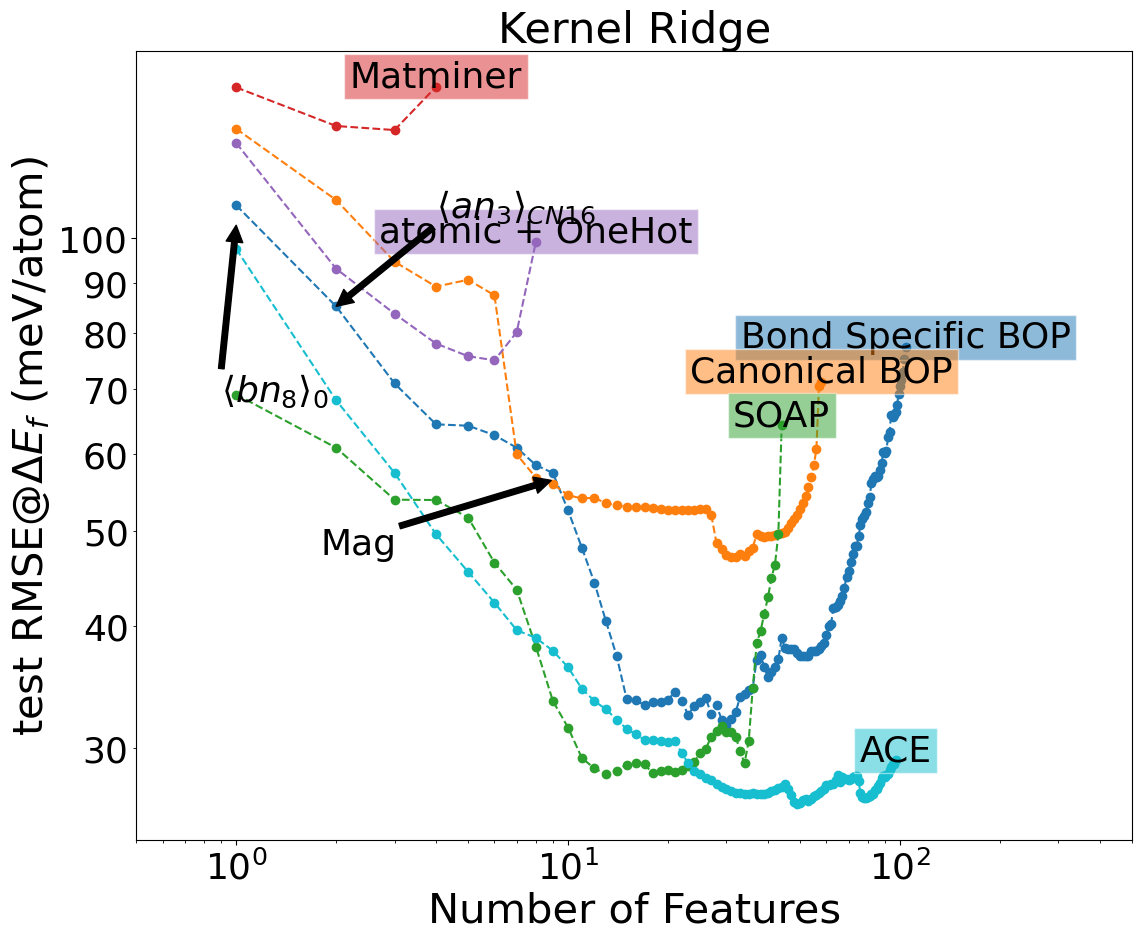

In [43]:
fig

## Feature Selection

In [44]:
iwanttoplot_all = [feature for feature in iwanttoplot if 'no CNAV' not in feature and 'dataset' not in feature and 'atomic' in feature]

In [45]:
iwanttoplot_all = {'dataset': 'atomic + OneHot', '0.7 Projections OS BOP': 'BOP', 'SOAP_specific': 'SOAP', 'ACE':'ACE'}

In [46]:
def plot_panel_learning_curves(feature_list: dict) -> list[matplotlib.axes._subplots.Axes]: 
    nplots = len(feature_list)
    width = 5*nplots
    fig, axes = plt.subplots(1, nplots, figsize=(width, 5*width/13), sharey = True)
    for (featurename, featurelabel), ax in zip(feature_list.items(), axes):
        combi = (ModelName, featurename)
        ax.set_title(featurelabel)
        results = FCresults[combi]
        for j, result in enumerate(results):
            x = np.linspace(1, result.shape[0], result.shape[0])
            sns.scatterplot(x, result['test']*1000, ax=ax)
        ax.set_yscale('log', subs=[2, 4, 6, 8, 10])
        ax.set_xscale('log')
        ax.xaxis.set_major_formatter(FormatStrFormatter("%.0f"))
    ax.set_ylim([19, 110])
    ax.yaxis.set_minor_formatter(FormatStrFormatter("%.0f"))
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.0f"))
    ax.tick_params(axis='y', which = 'minor')
    axes[0].set_xticks([1, 5, 10])
    axes[0].set_ylabel(r'test RMSE @$\Delta E_f$ (meV/at)')
    fig.supxlabel('Number of features')
    fig.tight_layout()
    return fig, axes
#    axes[i-1].set_xticklabels('')
#axes[0].yaxis.set_major_formatter(FormatStrFormatter("%.0e"))

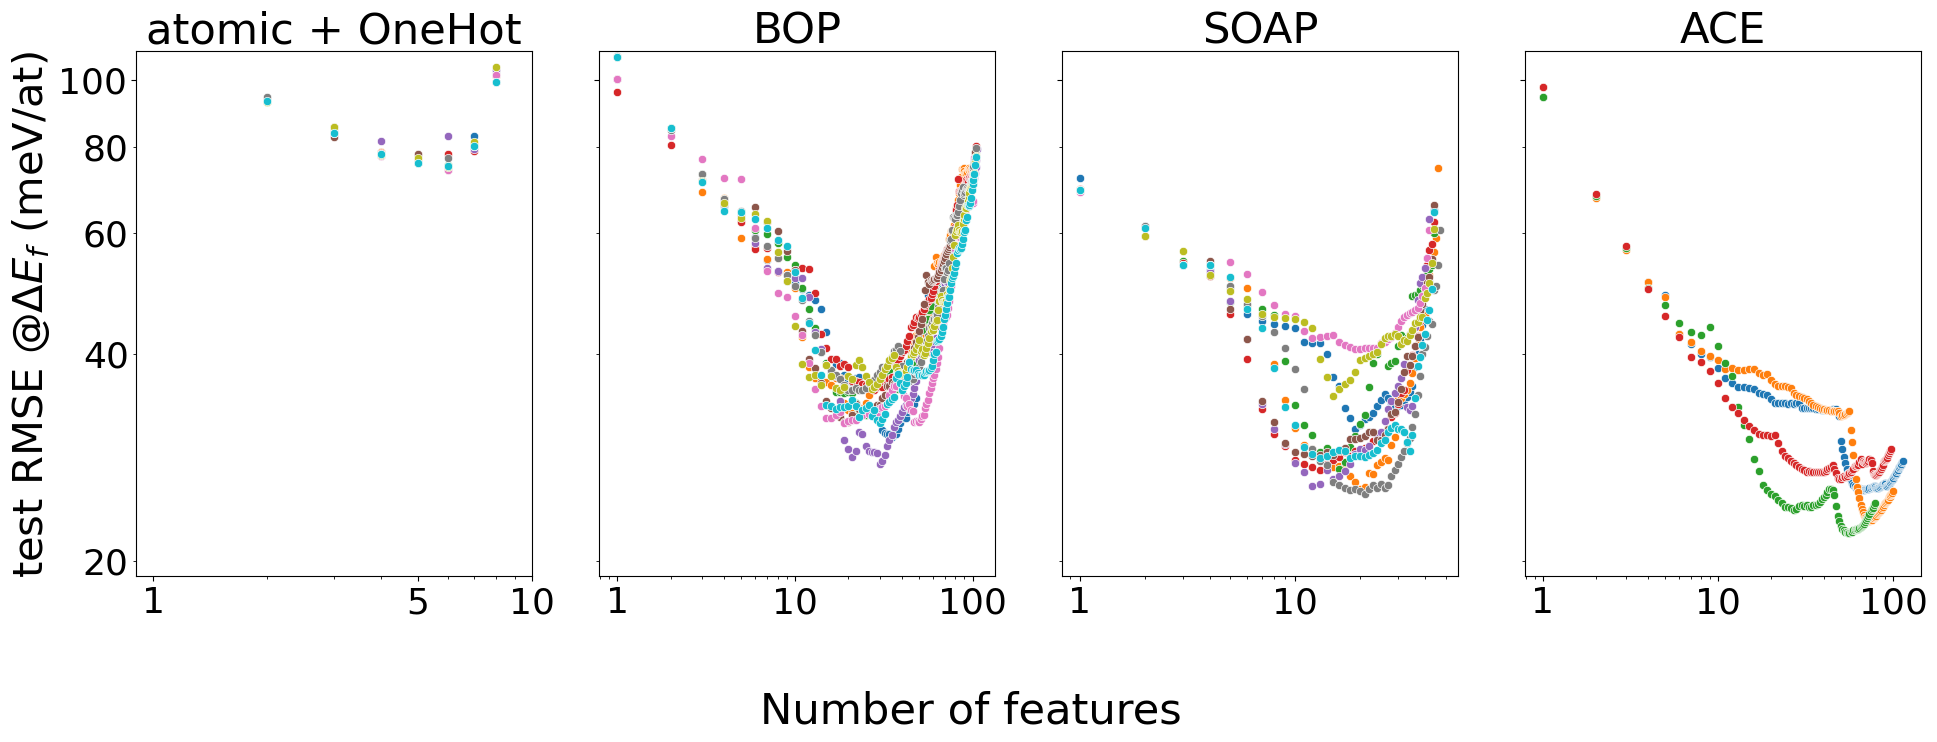

In [47]:
fig, axes = plot_panel_learning_curves(iwanttoplot_all)
nameinfile = ModelName.replace(' ','')
fig.savefig(os.path.join(DS.dataset, 'graphs', f'{DS.dataset}_{nameinfile}_learning_curves_tovote.pdf'))

## Feature transformers

In [48]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.base import RegressorMixin

In [49]:
def get_optimal_feature_score(FeatureScoreData:pd.core.frame.DataFrame):
    thisatmin = FeatureScoreData['test'].argmin()
    return FeatureScoreData[:thisatmin]

In [50]:
def get_optimal_features(FeatureScoreData:pd.core.frame.DataFrame):
    thisatmin = FeatureScoreData['test'].argmin()
    return FeatureScoreData.index[:thisatmin]

In [51]:
def filter_features (Features_DF: pd.core.frame.DataFrame, learning_curve = pd.core.frame.DataFrame):
    if 'params' not in learning_curve.columns:
        raise ValueError('the learning curve provided is not an evaluation of best features')
    columns = get_optimal_features(learning_curve)
    return Features_DF[columns]

def get_optimal_feature_names(Features_DF: pd.core.frame.DataFrame, learning_curve = pd.core.frame.DataFrame):
    columns = get_optimimal_features(learning_curve)
    return columns

In [52]:
class AverageEnsambleRegressor():
    def __init__(self, named_estimators = list[tuple[str, RegressorMixin]]):
        self.named_estimators_ : list[tuple[str, RegressorMixin]] = named_estimators

    def fit(self, _X : pd.core.frame.DataFrame , _Y : pd.core.series.Series) -> pd.core.series.Series:

        for name, estimator in self.named_estimators_:
            estimator.fit(_X, _Y)

    def predict(self, _X : pd.core.frame.DataFrame) -> pd.core.series.Series:

        self.predictions_ = pd.concat(
            [pd.Series(estimator.predict(_X), name=name, index=_X.index) for name, estimator in self.named_estimators_],
            axis=1
        )

        return self.predictions_.mean(axis=1)

    def get_prediction_std(self):
        if not hasattr(self, 'predictions_'):
            pdb.set_trace()
            raise NameError('you must fit the models first')

        err = self.predictions_.std(axis=1)
        return err

In [53]:
combi = (ModelName, '0.7 Projections OS BOP')

In [54]:
RegresorsBag = {}

In [55]:
from sklearn.ensemble import VotingRegressor

In [56]:
VotedScores = {}
AveragedScores = {}

In [57]:
voting_regressor = {}
average_regressor = {}
indexedregressorbag = {}

## Voting Regressor based on regressor bag

In [58]:
for combi, LearningCurveList in FCresults.items():
    RegresorsBag[combi] = []
    if combi[1] not in Features.keys():
        continue
    if combi[0] != ModelName:
        continue
    if len(LearningCurveList) < 1:
        continue
    print (combi)
    for LearningCurve in LearningCurveList:
        transformer = FunctionTransformer(
            filter_features, kw_args = {'learning_curve' : LearningCurve}, 
        )
        RegresorsBag[combi].append(copy.deepcopy(Models[ModelName])) 
        RegresorsBag[combi][-1].steps.insert(0, ['feature_selection', transformer])
        RegresorsBag[combi][-1].set_params(**LearningCurve.params.iloc[-1])

    indexedregressorbag[combi] = [(str(i), thisregressor) for i, thisregressor in enumerate(RegresorsBag[combi])]
    if len(indexedregressorbag) < 1:
        continue

    voting_regressor[combi] = VotingRegressor(indexedregressorbag[combi])
    voting_regressor[combi].fit(Features[combi[1]].loc[DS.samplesplit['train']], DS.target.loc[DS.samplesplit['train']])


    VotedScores[combi] = score_fitted_model(
        voting_regressor[combi], 
        Features[combi[1]].loc[DS.samplesplit['train']],
        Features[combi[1]].loc[DS.samplesplit['test']],
        DS.target[DS.samplesplit['train']],
        DS.target[DS.samplesplit['test']])

('Kernel Ridge', '0.6 Projections OS BOP')
('Kernel Ridge', '0.7 Projections OS BOP')
('Kernel Ridge', '0.8 Projections OS BOP')
('Kernel Ridge', 'Canonical BOP')
('Kernel Ridge', 'Projections OS BOP')
('Kernel Ridge', 'SOAP_specific')
('Kernel Ridge', 'atomic')
('Kernel Ridge', 'dataset')
('Kernel Ridge', '0.7 Projections OS BOP no CNAV')
('Kernel Ridge', 'Canonical BOP no CNAV')
('Kernel Ridge', 'dataset no CNAV')
('Kernel Ridge', 'atomic no CNAV')
('Kernel Ridge', 'SOAP_specific no CNAV')
('Kernel Ridge', 'ACE no CNAV')
('Kernel Ridge', 'ACE')


# SAVE THE REGRESSOR!

In [59]:
VotingRegressor

sklearn.ensemble._voting.VotingRegressor

In [60]:
regresorbag_file =os.path.join(DS.dataset, 'results', f'regressors_bag_{nameforfile}.pkl')

In [61]:
indexedbags_file = os.path.join(DS.dataset, 'results', f'indexed_bag_{nameforfile}.pkl')

In [62]:
regressor_file = os.path.join(DS.dataset, 'results', f'voting_regressor_{nameforfile}.pkl')

In [63]:
import joblib

In [64]:
joblib.dump(RegresorsBag, regresorbag_file)
joblib.dump(indexedregressorbag, indexedbags_file)
joblib.dump(voting_regressor, regressor_file)

['Fe-Mo/results/voting_regressor_KernelRidge.pkl']

In [65]:
voting_regressor = joblib.load(regressor_file)

In [66]:
os.path.exists(regressor_file)

True

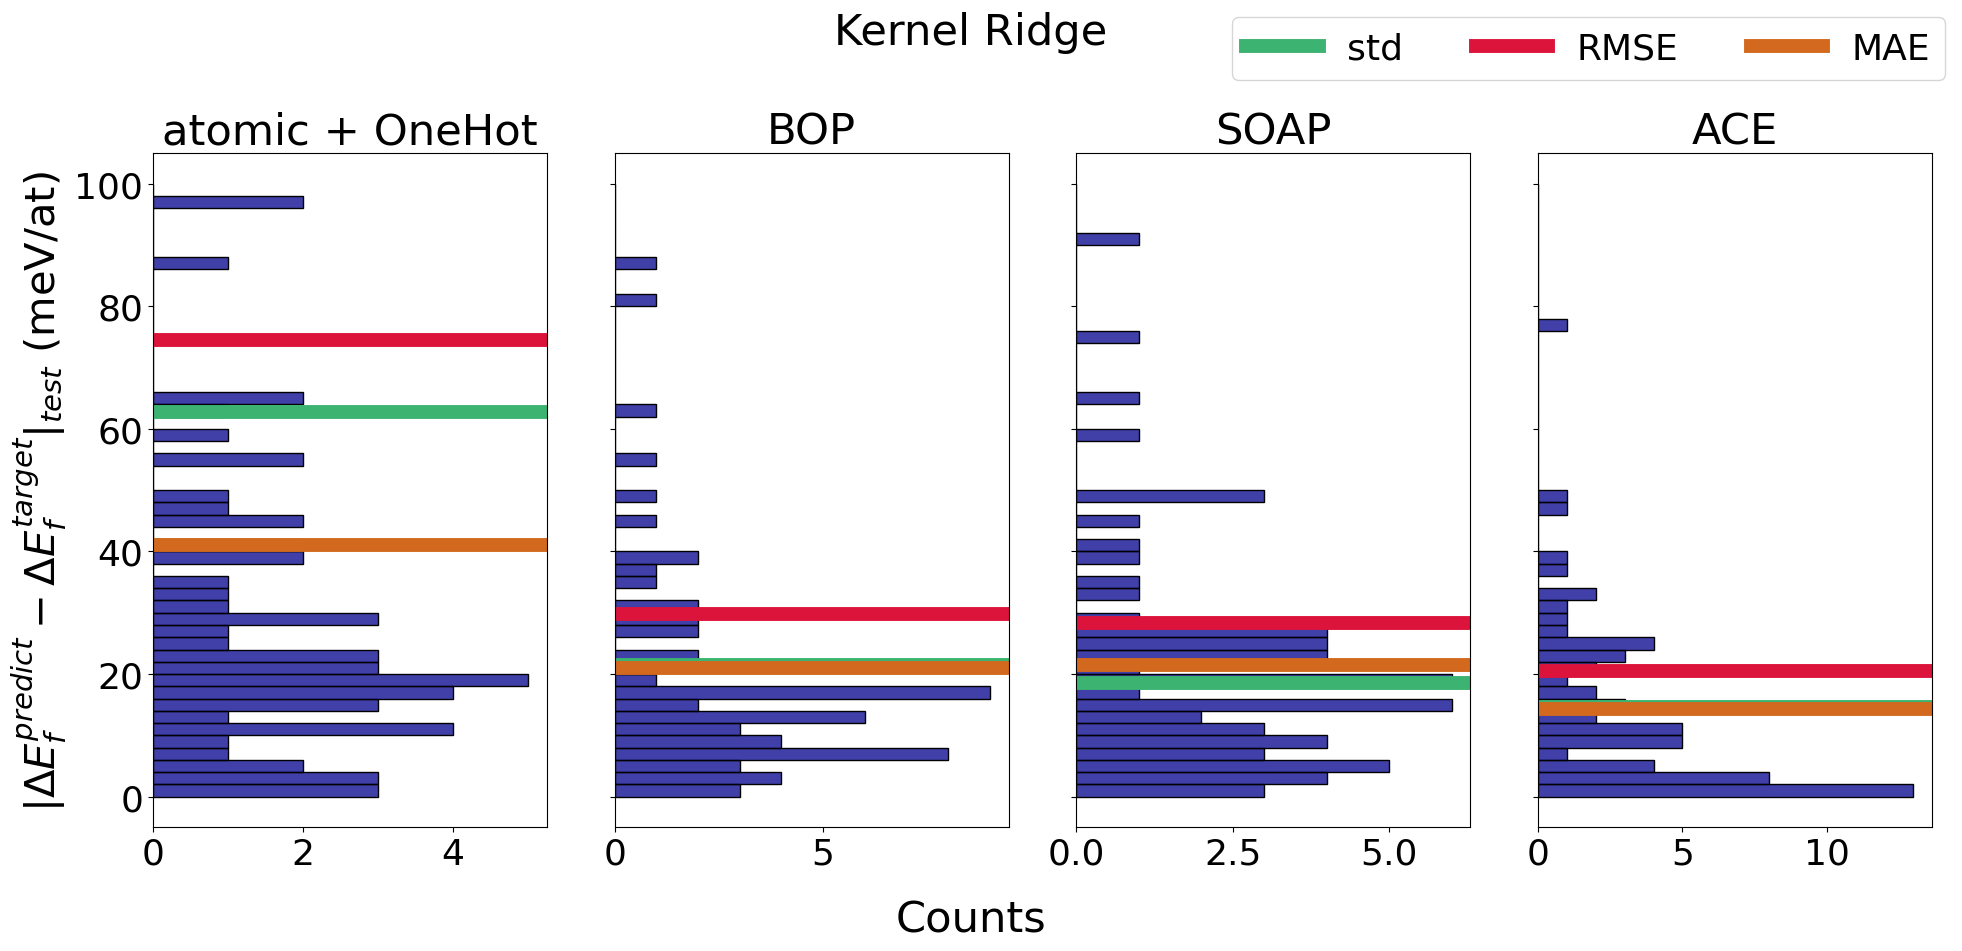

In [67]:
nplots = len(iwanttoplot_all)
width = nplots*5
fig, axes = plt.subplots(1, nplots, sharey = True, figsize=(width, width/2))
#for (combi, bagging_regressor), ax in zip(voting_regressor.items(), axes):
for (featurename, featuretag), ax in zip(iwanttoplot_all.items(), axes):
    if featurename not in Features.keys():
        continue
    combi = (ModelName, featurename)
    bagging_regressor = voting_regressor[combi]
    err_test = (bagging_regressor.predict(Features[featurename].loc[DS.samplesplit['test']]) - DS.target[DS.samplesplit['test']]).abs()
    rmse_test = np.sqrt((err_test**2).sum()/len(err_test))
    ax = sns.histplot(
        data=err_test,
        y=err_test.values*1000, 
        ax=ax, binrange=[0, 100],
        bins=50, 
        color = ['darkblue']
    )#, hue =DS.StructureNames[DS.samplesplit['test']])#.plot.hist( ax=ax)
    ax.set_xlabel('')
    ax.set_title(featuretag)
    ax.axhline(err_test.std()*1000, color='mediumseagreen', label = 'std', linewidth = 10)
    ax.axhline(rmse_test*1000, color='crimson', label = 'RMSE', linewidth = 10)
    ax.axhline(err_test.mean()*1000, label='MAE', color='chocolate', linewidth=10)
#    ax.get_legend().remove()
axes[0].set_ylabel(r'$|\Delta E_f ^{predict} - \Delta E_f ^{target}|_{test}$ (meV/at)')
fig.supxlabel('Counts', x=0.5, y=0.05)
fig.suptitle(ModelName)
fig.tight_layout()
leg_handles, leg_labels = axes[0].get_legend_handles_labels()
fig.legend(leg_handles, leg_labels, ncol=3)
fig_file_name = os.path.join(DS.dataset, 'graphs', f'{DS.dataset}_{nameforfile}_ErrorDistributions_{target_case}.pdf')

In [68]:
VotedScores = pd.DataFrame.from_dict(VotedScores, orient = 'index')

In [69]:
VotedScores = VotedScores.sort_values('test', ascending = False).sort_index(level=1)

In [70]:
VotedScores

test     train
Kernel Ridge 0.6 Projections OS BOP          0.032330  0.025913
             0.7 Projections OS BOP          0.029837  0.008938
             0.7 Projections OS BOP no CNAV  0.050276  0.032414
             0.8 Projections OS BOP          0.045273  0.025014
             ACE                             0.020448  0.030571
             ACE no CNAV                     0.037354  0.014041
             Canonical BOP                   0.071510  0.067207
             Canonical BOP no CNAV           0.077252  0.070964
             Projections OS BOP              0.037796  0.008869
             SOAP_specific                   0.028275  0.020549
             SOAP_specific no CNAV           0.039712  0.040209
             atomic                          0.142624  0.153541
             atomic no CNAV                  0.278512  0.284192
             dataset                         0.074479  0.070611
             dataset no CNAV                 0.280363  0.284930

In [71]:
VotedScores.to_pickle(os.path.join(DS.dataset,'results', f'{DS.dataset}_{ModelName}_OptimalScores_{target_case}.pkl'))

In [72]:
PlotVotedScores = 1000*VotedScores[~VotedScores.index.levels[1].str.contains('^0.6|^0.8')]

In [73]:
PlotVotedScores.unstack(level=0).sort_index()

,test,train
,Kernel Ridge,Kernel Ridge
0.7 Projections OS BOP,29.836702,8.937756
0.7 Projections OS BOP no CNAV,50.276438,32.413904
ACE,20.447985,30.570776
ACE no CNAV,37.354096,14.040760
Canonical BOP,71.509674,67.206687
Canonical BOP no CNAV,77.251967,70.964446
Projections OS BOP,37.796037,8.868526
SOAP_specific,28.274600,20.548975
SOAP_specific no CNAV,39.712380,40.208511


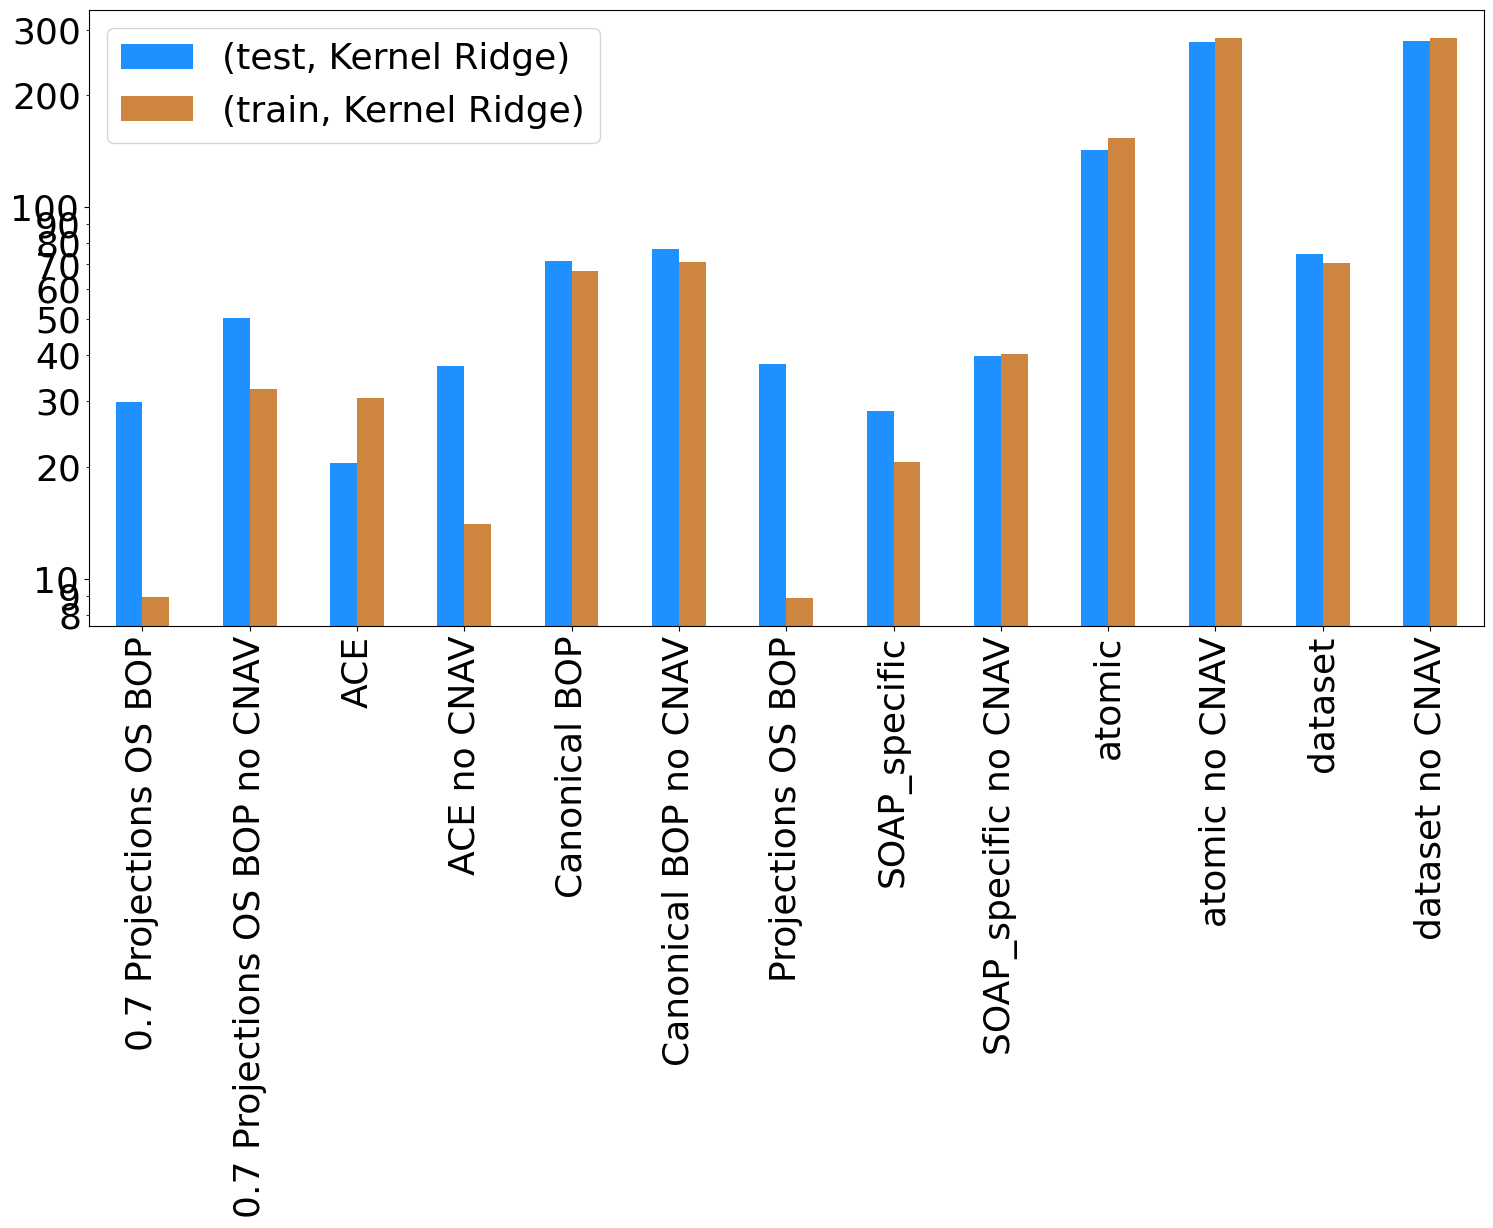

In [74]:
ax = PlotVotedScores.unstack(level=0).sort_index().plot.bar(
    color = ['dodgerblue', 'peru']
)#.sort_values(by=('test', ModelName), ascending=False)*1000).plot.bar()

ax.set_yscale('log')
ax.get_legend().set_title('')
ax.tick_params(axis='y', which = 'minor')                                                                                                     
ax.yaxis.set_minor_formatter(FormatStrFormatter("%.0f"))
ax.yaxis.set_major_formatter(FormatStrFormatter("%.0f"))

# Prediction line 

In [75]:
from sklearn.ensemble._voting import VotingRegressor as type_voting_regressor

In [76]:
def get_bag_of_predictions(bag_of_regressors : type_voting_regressor, features_df  : pd.core.frame.DataFrame):
    bag_of_predictions = {}
    for name, regressor_in_bag in enumerate(bag_of_regressors):
        bag_of_predictions[name] = regressor_in_bag.predict(features_df)
        bag_of_predictions [name] = pd.Series(bag_of_predictions[name],name=name,  index=features_df.index)
    return pd.concat(bag_of_predictions, axis=1)
    

In [77]:
predictions={}
stds={}
Prediction = {} 

In [78]:
for name, regressor in voting_regressor.items():
    Prediction[name] = regressor.predict(Features[name[1]])
    Prediction[name] = pd.DataFrame(Prediction[name], index = Features[name[1]].index, columns=[DS.target_name])
    predictions[name] = get_bag_of_predictions(regressor.estimators_, Features[name[1]])
    stds[name] = predictions[name].std(axis=1)

# Predicted BS 

In [79]:
predictedBS = copy.copy(DS.BS.loc[DS.target.index])

In [80]:
for combi, prediction in Prediction.items():
    predictedBS[f'EF_nmhcp_{combi[1]}'] = prediction

In [81]:
predictedBS.filter(regex='EF_nmhcp_*')

,EF_nmhcp,EF_nmhcp_0.6 Projections OS BOP,EF_nmhcp_0.7 Projections OS BOP,EF_nmhcp_0.8 Projections OS BOP,EF_nmhcp_Canonical BOP,EF_nmhcp_Projections OS BOP,EF_nmhcp_SOAP_specific,EF_nmhcp_atomic,EF_nmhcp_dataset,EF_nmhcp_0.7 Projections OS BOP no CNAV,EF_nmhcp_Canonical BOP no CNAV,EF_nmhcp_dataset no CNAV,EF_nmhcp_atomic no CNAV,EF_nmhcp_SOAP_specific no CNAV,EF_nmhcp_ACE no CNAV,EF_nmhcp_ACE
Fe_pv8.A15.FM,0.085535,0.099471,0.085170,0.128860,0.116230,0.100885,0.075020,0.184100,0.154339,0.111518,0.162329,-0.104316,-0.058467,0.105638,0.101025,0.082403
Fe_pv12.C14.FM,0.149303,0.176340,0.147858,0.206939,0.177876,0.164902,0.162849,0.183492,0.233378,0.165492,0.223613,-0.104316,-0.058467,0.159902,0.166794,0.193749
Fe_pv24Mo_sv5.chi-BBAA.FM,0.058514,0.011285,0.050518,0.052038,0.035538,0.031173,0.057646,0.179214,0.033902,0.040570,0.038896,-0.068739,-0.058467,0.055606,0.032368,0.040303
Fe_pv25Mo_sv4.chi-ABAA.FM,0.063911,0.060654,0.063708,0.061827,0.063495,0.063979,0.069785,0.174336,0.071499,0.063622,0.071981,-0.075854,-0.058467,0.076971,0.055003,0.062617
Fe_pv24.C36.FM,0.145580,0.198760,0.149273,0.214085,0.309763,0.169927,0.164994,0.177627,0.246713,0.176193,0.360934,-0.104316,-0.058467,0.177636,0.184390,0.202361
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv25Mo_sv4.chi-ABAA.NM,0.057857,0.094497,0.074946,0.055841,0.069924,0.066124,0.072477,0.174336,0.071499,0.130966,0.071981,-0.075854,-0.058467,0.111858,0.080904,0.079744
Fe_pv16Mo_sv8.C36-BBAAA.NM,-0.016932,0.004852,-0.013989,-0.010192,-0.062552,-0.012962,-0.022347,0.216295,0.028491,0.014767,-0.068925,-0.035533,-0.058467,-0.010970,-0.009119,-0.008838
Fe_pv8Mo_sv4.C14-BAA.NM,-0.032294,-0.018184,-0.029460,-0.024743,0.050162,-0.031853,-0.021326,0.215992,-0.044446,-0.003078,-0.002473,-0.035533,-0.058467,-0.026062,-0.032547,-0.014629
Fe_pv4.fcc-cubic.NM,0.079070,0.132520,0.064253,0.133656,0.098824,0.098847,0.029504,0.147302,0.118489,0.120417,0.061582,-0.104316,-0.058467,0.117864,0.115851,0.110598


## save the prediction

In [82]:
predictedBS.to_pickle(os.path.join(DS.dataset, 'results', f'{DS.dataset}_{ModelName}_PredictedBS.pkl'))

In [83]:
#iwanttoplot = {'atomic':'Matminer',
iwanttoplot = {'Canonical BOP': 'Canonical BOP', '0.7 Projections OS BOP':'0.7 Projections OS BOP'}
#iwanttoplot = {'dataset': 'dataset', 'Projections OS BOP':'Projections OS BOP'}

Canonical BOP Canonical BOP
0.7 Projections OS BOP 0.7 Projections OS BOP


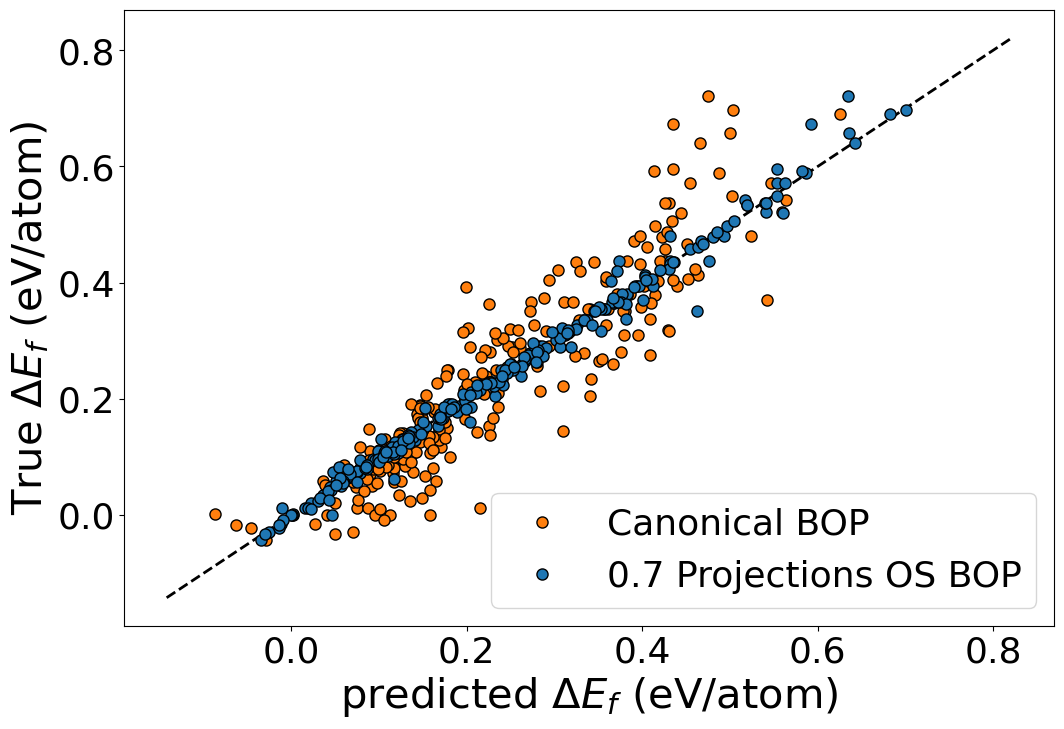

In [84]:
x_y = np.linspace(DS.target.min()-0.1, DS.target.max()+0.1, 2)
fig, ax = plt.subplots(figsize=(12,8))
ax.plot(x_y, x_y, '--k', lw=2)
for name, legend in iwanttoplot.items():
    print(name, legend)
    legend = legend.replace('dataset', 'polyhedra')
    combi = (ModelName, name)
    if combi not in Prediction.keys():
        print(f'{combi} has not been processed yet')
        continue
    ax.plot(Prediction[combi].values, DS.target.values, 'o', markersize=8, markeredgecolor='k', color=colors[name], label=legend, )
ax.set_xlabel(r'predicted $\Delta E_f$ (eV/atom)')
ax.set_ylabel(r'True $\Delta E_f$ (eV/atom)')
ax.legend()
fig.savefig(os.path.join(DS.dataset,'graphs', f'{DS.dataset}_{ModelName}_predictionline_{target_case}.pdf'))

# Recursivity

REDO RECURSIVITY TESTS
 - redefine model
 - refit model

In [85]:
Tester = DatasetTester()

In [86]:
from importlib.machinery import SourceFileLoader
Tester = SourceFileLoader('Tester', 'Tools/DatasetTools/DatasetOperator.py').load_module().DatasetTester()
# from Tools.DatasetTools.DatasetOperator import Dataset
# DS = SourceFileLoader('DS', 'Tools/DatasetTools/DatasetOperator.py').load_module().Dataset('Fe-Mo')
# Tester = SourceFileLoader('Tester', 'Tools/DatasetTools/DatasetOperator.py').load_module().DatasetTester()
# samplesplit = DS.get_samplesplit()

In [87]:
import copy

In [88]:
RecursivityModels = copy.deepcopy(Models[ModelName])

# Fits on reduced features 

In [89]:
ReducedFittedModels = {}

In [90]:
Reduced_features_fitting_location = os.path.join(DS.resultslocation, f'ReducedFeaturesCVSearch_{target_case}.pkl')

In [91]:
if os.path.exists(Reduced_features_fitting_location):
    with open(Reduced_features_fitting_location, 'rb') as pkl:
        ReducedFittedModels = pickle.load(pkl)

In [92]:
MO.modeloptions

{'Kernel Ridge': {'regressor__alpha': [1.0, 0.1, 0.01],
  'regressor__kernel': ['polynomial'],
  'regressor__degree': [2, 3, 4, 5],
  'regressor__coef0': [0, 1, 2, 3, 4, 5]}}

In [93]:
maxorders = [8, 10, 12, 14, 16]
for name, model in Models.items():
    if name != ModelName:
        continue
    progress = tqdm(product(Features.items(), maxorders), total=len(maxorders)*len(Features))
    for (key, features), maxorder in progress:  # maxorder in range(4,9):
        progress.set_description(name+', '+key+', '+str(maxorder)+':  ')
        if (name, key, maxorder) in ReducedFittedModels.keys():
            continue
        if 'no CNAV' in key:
            continue
        if 'BOP' not in key:
            continue
        if 'Projections' not in key:
            continue
        if (name, key, maxorder) in ReducedFittedModels.keys():
            continue
        if maxorder < 10:
            regexstr = f'^(?!.*_[{maxorder}-9]_.*|.*_1[0-9]_.*)'
        else:
            regexstr = f'^(?!.*_1[{maxorder - 10}-9]_.*)'
#        for key, features in progress: #Features.items():
        model = GridSearchCV(
            Models[name],
            MO.modeloptions[name], 
            scoring='neg_root_mean_squared_error', 
            cv = 5,#samplefolds,
            return_train_score= True,
        )
        if 'BOP' in key:
            reducedfeatures = features.filter(regex=regexstr)
        else:
            reducedfeatures = features
        ReducedFittedModels[(name, key, maxorder)] = model.fit(reducedfeatures, DS.target)

  0%|          | 0/190 [00:00<?, ?it/s]

In [94]:
with open(Reduced_features_fitting_location, 'wb') as pkl:
    pickle.dump(ReducedFittedModels, pkl)

In [95]:
somecombi = (ModelName, 'Projections BOP')

In [96]:
features_in_reduced = pd.Index(ReducedFittedModels[somecombi+(16,)].feature_names_in_)

In [97]:
best_scores_reduced = collect_best_scores(ReducedFittedModels)

In [98]:
model = best_scores_reduced.index.get_level_values(0)

In [99]:
test_scores_vs_max = best_scores_reduced.unstack().transpose().loc['test'].dropna(axis=1)

In [100]:
full_model_test_scores = best_scores_reduced.unstack().transpose().loc['test']

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


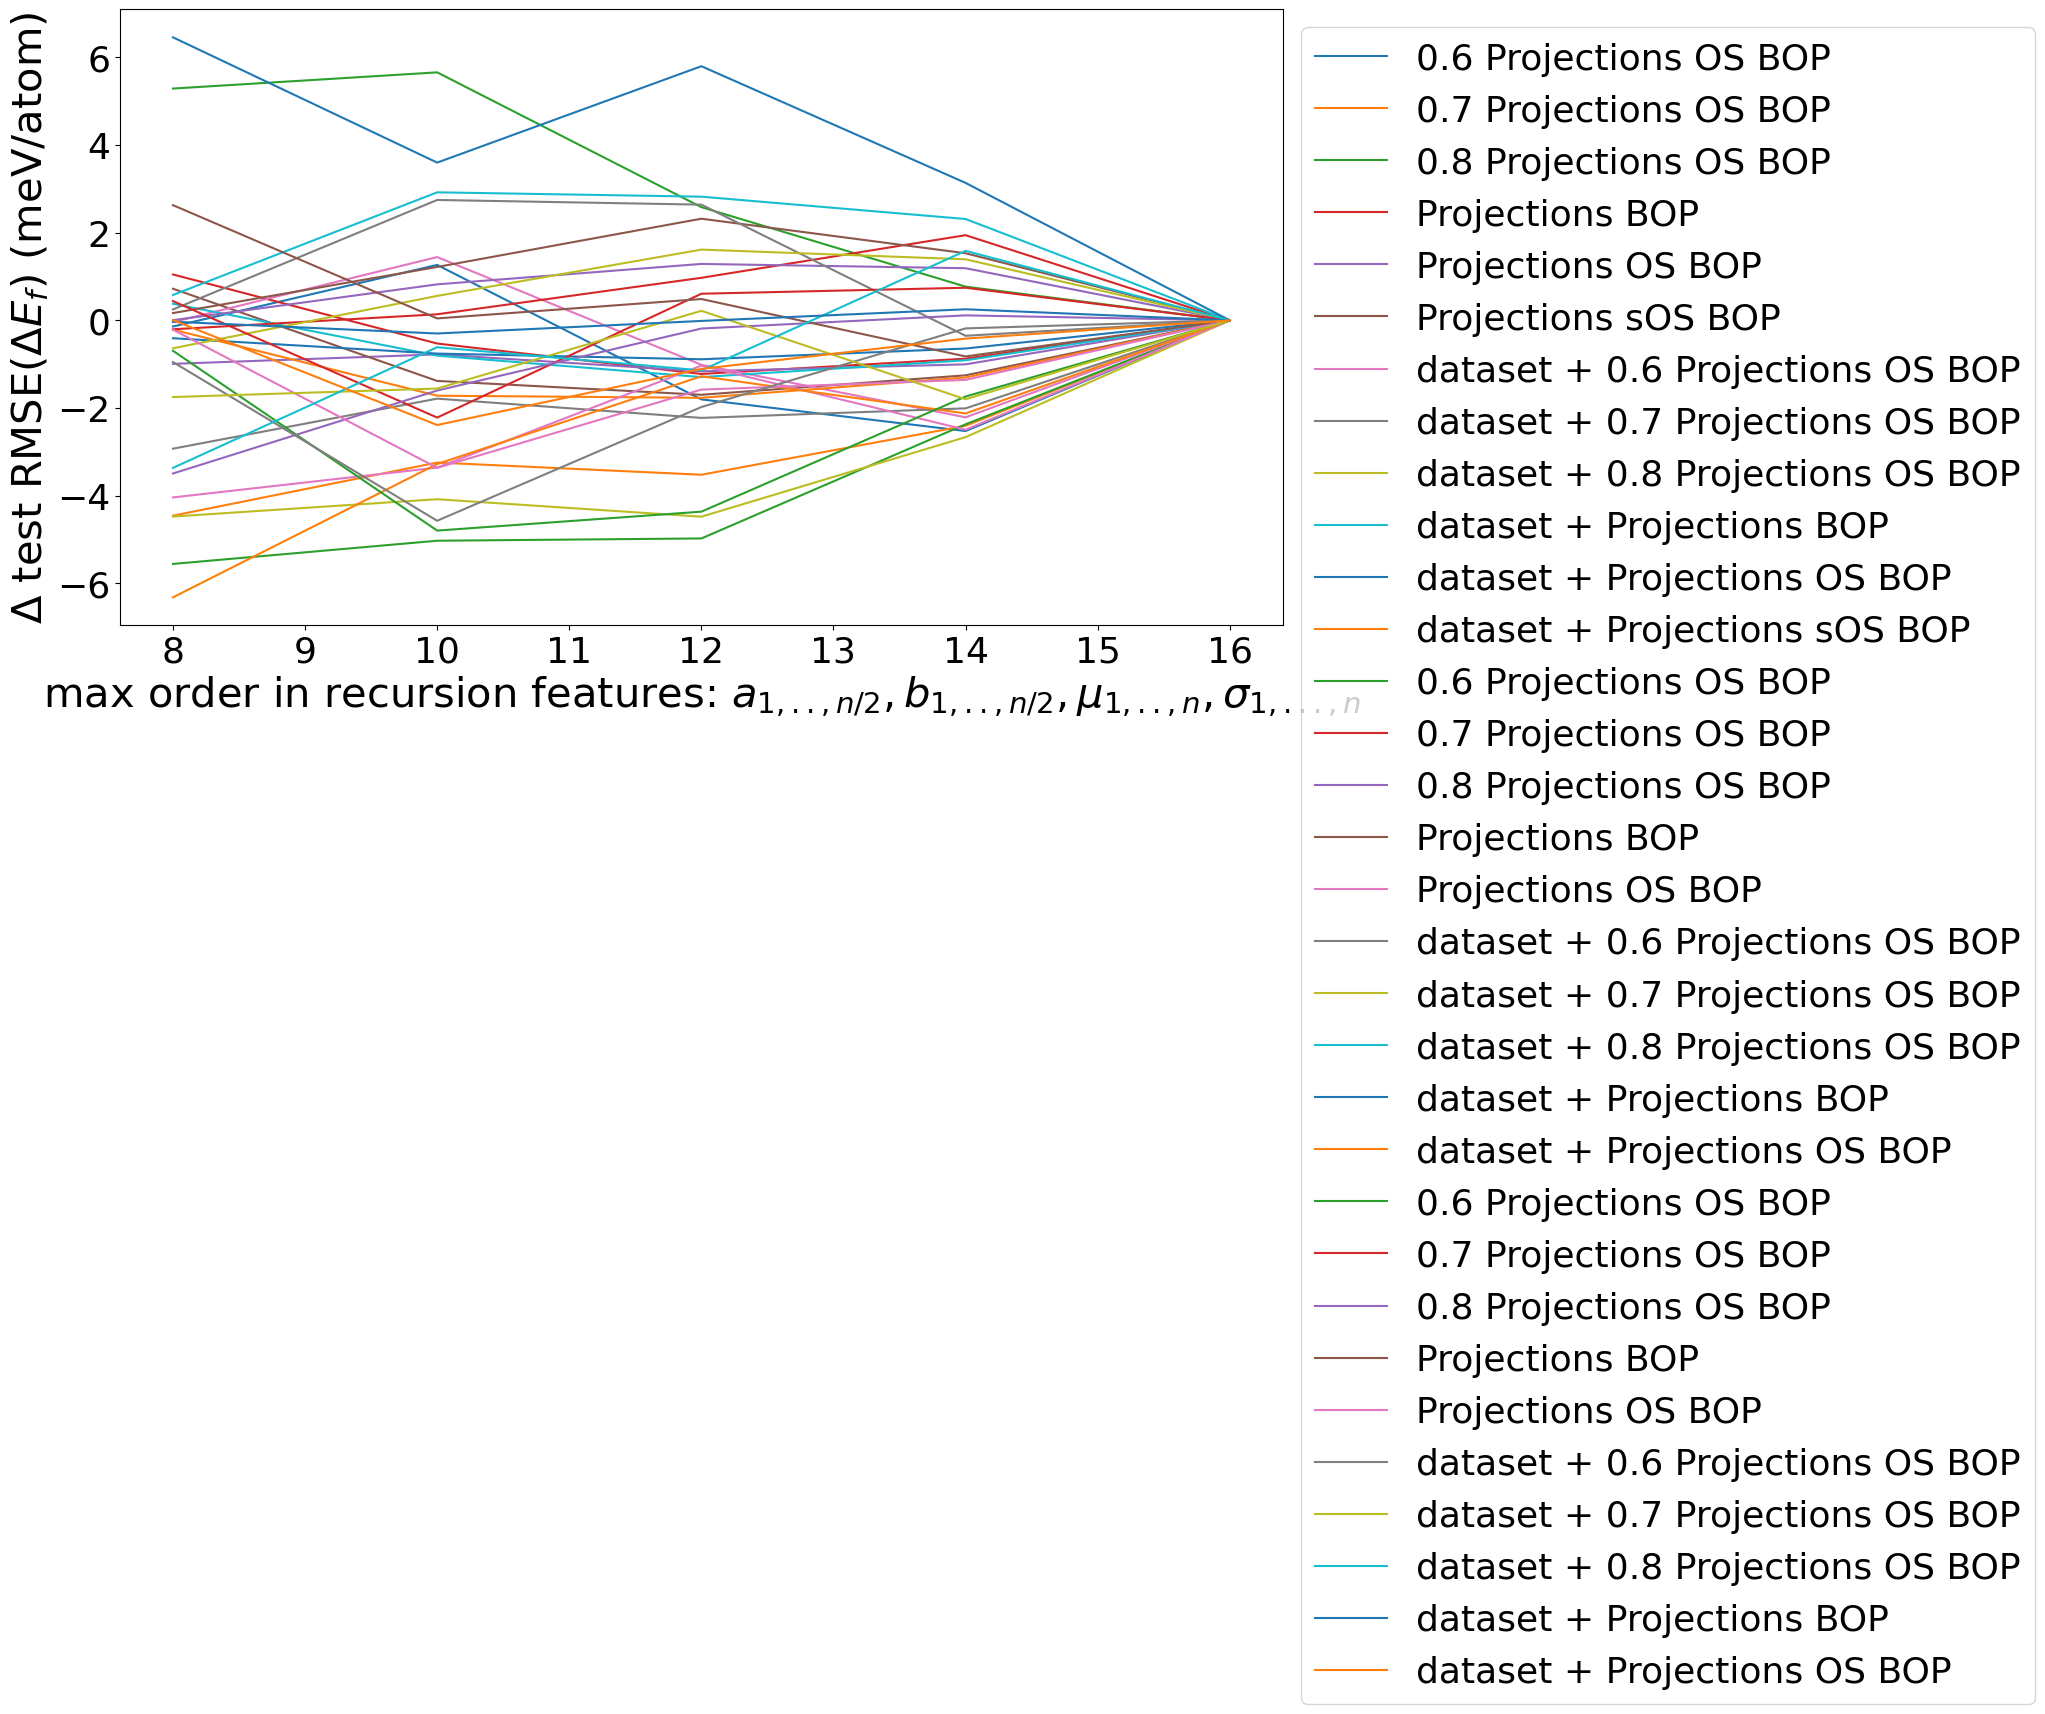

In [101]:
fig, ax = plt.subplots(figsize=(15, 8))
for combi in test_scores_vs_max.columns:
#    if 'BOP' not in combi[1]:
#        continue
#    if 'Canonical' in combi[1]:
#        continue
#    if 'dataset' not in combi[1]:
#        continue
    drmse = (test_scores_vs_max[combi].values - test_scores_vs_max[combi].values[-1])*1000  # - full_model_test_scores[combi[0]][combi[1]]*1000
    l = ax.plot(test_scores_vs_max[combi].index, drmse, label=combi[1])[0]
#    ax.axhline(full_model_test_scores[combi[0]][combi[1]]*1000,ls='--', color=l.get_color())
ax.legend(bbox_to_anchor = (1, 1))
ax.set_ylabel(r'$\Delta$ test RMSE($\Delta E_f$) (meV/atom)')
ax.set_xlabel(r'max order in recursion features: $a_{1,..,n/2}, b_{1,..,n/2}, \mu_{1,..,n}, \sigma_{1,...,n}$')
fig.tight_layout()
fig.savefig(os.path.join(DS.dataset, 'graphs', f'{DS.dataset}_full_recursivity_{target_case}.eps'))

# Feature Importances 

In [102]:
def get_importances(voting_regressor):
    importances = {}
    for combi, estimator in voting_regressor.items():
        print(combi[1])
        X = DS.Features[combi[1]]#[selected]
        allimportances = get_importances(estimator , X,  DS.target)
        importances[combi] =allimportances #  [allimportances['importances_mean']>=allimportances['importances_mean']['random']]
    for (modelname, name),timportances in importances.items():
        timportances.sort_values(by='importances_mean', inplace=True, ascending=False)
    return importances


In [103]:
def plot_importances(importances):
    for name, timp in importances.items():
        fig, ax = plt.subplots(figsize=(12, 8))
        x = timp['importances_mean'][:20]
        sns.barplot(y=timp.index[:20], x=x , ax=ax, color='Purple')
        ylabels = [get_str_formatted(fname) for fname in x.index]
        ax.set_xscale('log')
        ax.set_xlabel('permutation importance')
        ax.set_yticklabels(ylabels, fontsize=12)
        fig.suptitle(name[1].replace('dataset', 'polyhedra'))
        fig.tight_layout()

# Errors by phase by model

In [104]:
train_errors = {}
rmse = {}

In [105]:
absolute_errors = {}

In [106]:
for combi, thisprediction in Prediction.items(): # voting_regressor.items():
    if 'sOS' in combi[1]:
        continue
    print(combi)
    absolute_errors[combi] = thisprediction.sub(DS.target, axis=0)
    rmse[combi] = {}
    for phase in DS.BS.Phase.unique():
        thiserrors = absolute_errors[combi][DS.BS.Phase == phase]**2
        rmse[combi][phase] =  np.sqrt(thiserrors.sum()/len(thiserrors)).values[0]
    rmse[combi]['total'] = np.sqrt((thisprediction.sub(DS.target, axis=0)**2/len(thisprediction)).sum(axis=0)).values[0]
    rmse[combi]['test'] = np.sqrt(
        (
            (thisprediction.loc[DS.samplesplit['test']].sub(DS.target[DS.samplesplit['test']], axis=0)**2).sum()/len(DS.samplesplit['test'])
        ).values[0]
    )

('Kernel Ridge', '0.6 Projections OS BOP')
('Kernel Ridge', '0.7 Projections OS BOP')
('Kernel Ridge', '0.8 Projections OS BOP')
('Kernel Ridge', 'Canonical BOP')
('Kernel Ridge', 'Projections OS BOP')
('Kernel Ridge', 'SOAP_specific')
('Kernel Ridge', 'atomic')
('Kernel Ridge', 'dataset')
('Kernel Ridge', '0.7 Projections OS BOP no CNAV')
('Kernel Ridge', 'Canonical BOP no CNAV')
('Kernel Ridge', 'dataset no CNAV')
('Kernel Ridge', 'atomic no CNAV')
('Kernel Ridge', 'SOAP_specific no CNAV')
('Kernel Ridge', 'ACE no CNAV')
('Kernel Ridge', 'ACE')


In [ ]:
fig, axes = plt.subplots(len(rmse)-1, 1, sharex=True, figsize=(10, 5*len(rmse)))
for (combi, thiserrors), ax in zip(absolute_errors.items(), axes):
    sns.violinplot(
        x=absolute_errors[combi][target_case].map(np.log10), 
        y=DS.StructureNames, hue=DS.Features['dataset']['Mag'], split=True, ax=ax
    )
    ax.axvline(np.log10(rmse[combi]['total']),color='k', label='rmse')
    ax.get_legend().remove()
    ax.set_xlabel('')
    ax.set_ylabel(combi[1].replace('_specific', ''))
fig.tight_layout()

In [ ]:
rmsedf = pd.DataFrame.from_dict(rmse, orient = 'index')

In [ ]:
rmsedf.sort_values(by=(ModelName, '0.7 Projections OS BOP'), axis = 1, inplace=True)

In [ ]:
rmsedf.sort_values(by='total', inplace=True)

In [ ]:
from matplotlib.colors import LogNorm, Normalize
ax = sns.heatmap(rmsedf.loc[ModelName]*1000,  cbar_kws={'label': 'RMSE (meV /  at)'}, norm=LogNorm())

# convex hulls (binaries only)

In [ ]:
combi = (ModelName, 'Projections OS BOP')

In [ ]:
from Tools.DatasetTools.Tools import Plotting#, PlottingChulls
P = Plotting()

In [ ]:
class PlottingChulls:
     
    def clean_bad_populated(thephasesBS, return_removed = False):
        remove = []
        for mag, phasesbs in thephasesBS.items():
            for phase, bs in phasesbs.items():
                if len(bs) < 3:
                    remove.append((mag, phase))
        removed = [thephasesBS[remove_mag].pop(remove_phase) for (remove_mag, remove_phase) in remove]
        if return_removed:
            return removed

    def make_palette_forlist(NamesOfValues: list, palette_name = 'tab20'):
        palette = sns.color_palette(palette_name, n_colors = len(NamesOfValues)+1)
        colors = {name: color for name, color in zip(NamesOfValues, palette)}
        return colors


In [ ]:
iwanttoplotchull = ['R', 'mu', 'C14', 'C36','sigma', 'bcc', 'hcp']

In [ ]:
DS.components

In [ ]:
def get_bs_byphase(theBS):
    verts = {}
    chulls = {}
    phasepoints = {}
    return {mag: {phase: theBS[(theBS.Phase == phase) & theBS.index.str.contains(mag)] for phase in theBS.Phase.unique()} for mag in ['FM', 'NM', '']}

In [ ]:
PredictedPhasesBS = get_bs_byphase(predictedBS)

In [ ]:
PhasesBS = get_bs_byphase(DS.BS)

In [ ]:
removed = PlottingChulls.clean_bad_populated(PredictedPhasesBS, return_removed=True)

In [ ]:
plt.rc('font', size=20)
plt.rc('xtick', labelsize=26)
plt.rc('ytick', labelsize=26)
plt.rc('axes', labelsize=26)

In [ ]:
P = Plotting()

In [ ]:
remove_bs = PlottingChulls.clean_bad_populated(PhasesBS)

In [ ]:
target_case

In [ ]:
def plot_chull(
    thePhasesBS,
    theproperty, 
    mag_list = None,
    plot_points = True,
    plot_only = [], 
    line_styles = '-',
    figs_mag = {},
    ax_mag = {},
):
    palettename = 'tab20c'
    for mag, PhaseBS in  thePhasesBS.items():
        if mag not in mag_list:
            continue
        points = P.get_x_ef_points(PhaseBS, DS.components, property=theproperty)
        chulls =  P.get_convex_hulls(PhaseBS, DS.components, getproperty = theproperty, return_points = False)
        palette = PlottingChulls.make_palette_forlist(PhaseBS.keys())
        if len(plot_only)>0:
            palette = {name: color for name, color in palette.items() if name in plot_only} 
        if mag not in figs_mag.keys():
            figs_mag[mag],  ax_mag[mag] = plt.subplots(figsize=(12,8))
        fig = figs_mag[mag]
        ax = ax_mag[mag]
        labels=[]
        handles = []
        for phase, chull in chulls.items():
            if len(plot_only) > 0:
                if phase not in plot_only:
                    continue
            for visible_facet in chull.simplices[chull.good]:
                if plot_points:
                    ax.plot(points[phase][:,0] , points[phase][:,1], 'o', color = palette[phase])
                l = ax.plot(chull.points[visible_facet,0], chull.points[visible_facet,1],line_styles,  color=palette[phase], linewidth = 4, markersize=10, markeredgecolor='k')
            handles.append(l[0])
            labels.append(phase)
        leg = ax.legend(handles, labels, bbox_to_anchor=(1.01,1), title=mag)
        setlw = [ha.set_linewidth(5) for ha in leg.get_lines() ]
        ax.set_ylabel(r'$\Delta E _f$ (eV/atom)')
        ax.set_xlabel(rf'$x_{{{DS.components[0]}}}$')
        fig.tight_layout()
        figs_mag[mag] = fig
        ax_mag[mag] = ax
    return figs_mag, ax_mag 

InvalidIndexError: (slice(None, None, None), 0)

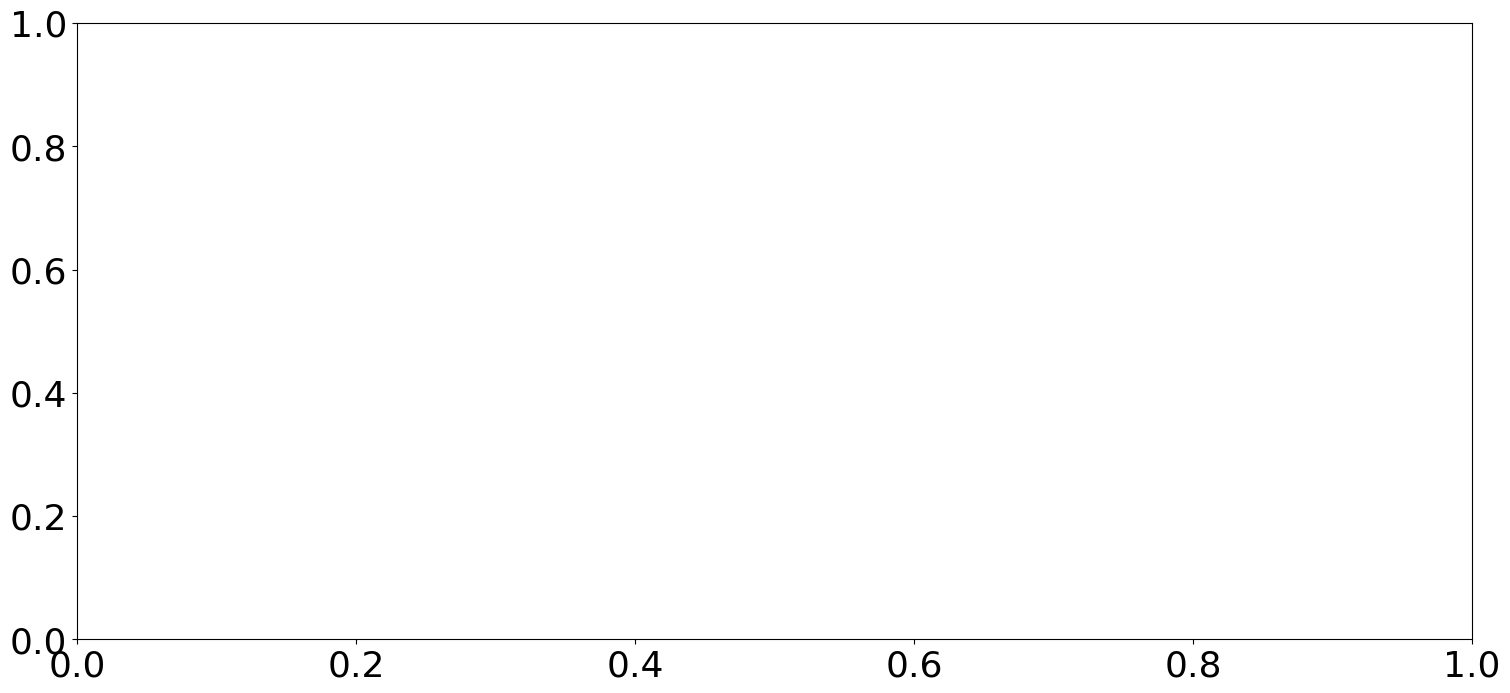

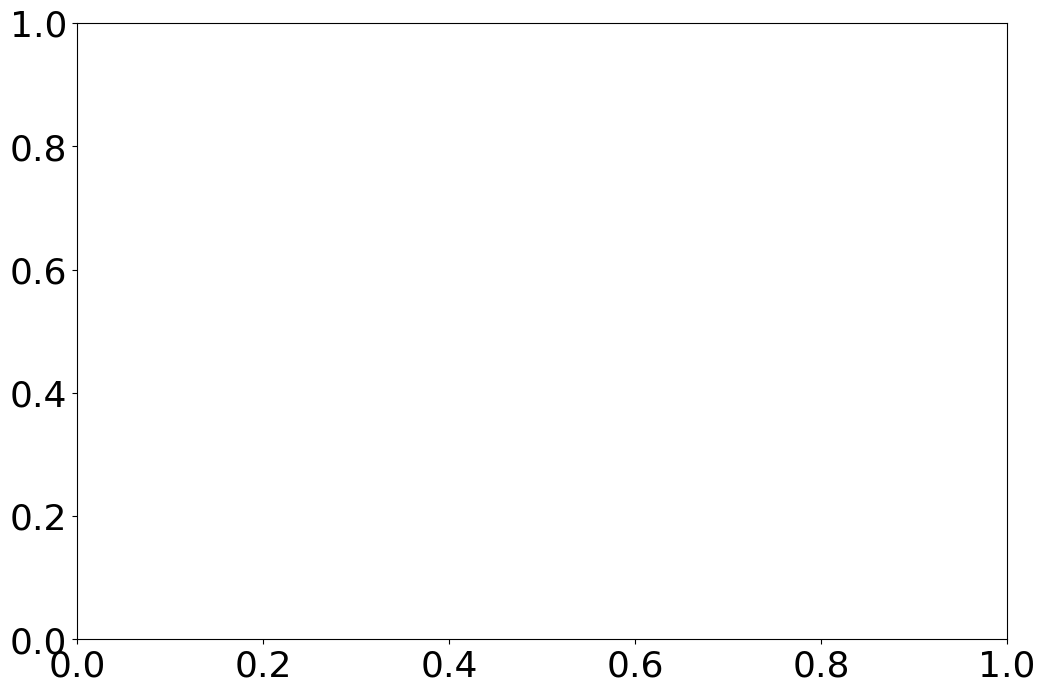

In [126]:
#del newfigs
#del newaxs
fig, ax = plt.subplots()
newfigs, newaxs = plot_chull(PhasesBS, theproperty=target_case, mag_list='', plot_only=iwanttoplotchull)
newfigs[''].savefig(f'Fe-Mo/graphs/Fe-Mo_ConvexHull_{ModelName}_.pdf')
#teo_figs, teo_axs = plot_chull(PredictedPhasesBS, theproperty=target_case+'_ACE', mag_list=[''], plot_points=False, plot_only=iwanttoplotchull, figs_mag=newfigs, ax_mag=newaxs)

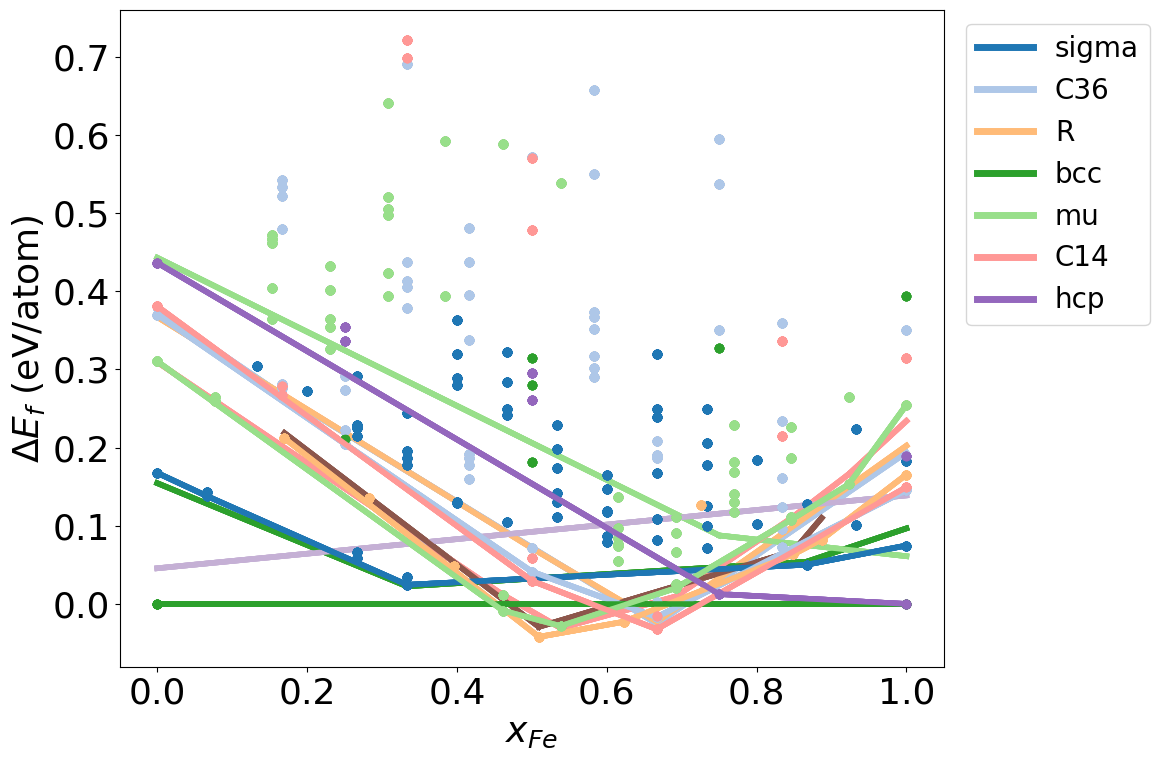

In [152]:
newfigs['']

In [146]:
newfigs[''].savefig(os.path.join(DS.dataset, 'graphs',f'{DS.dataset}_ConvxHulls_{target_case}_.eps' ))

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [ ]:
sns.histplot(x=DS.StructureNames)